## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this first laboratory we will see a few ways to exploit and adapt pre-trained models to solve new problems. We will start first by downloading and instantiating a new dataset and establishing a stable and reproducible baseline model based on a pre-trained CNN.

---

## Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline

For this laboratory we will work with [The German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/) [1]. We will begin, not with *detection*, but with a simpler traffic sign *classification* problem. This has two advantages: (1) the images are *smaller* than in the detection benchmark; and (2) a wrapper for the GTSRB dataset is conveniently included in the `torchvision` library.  

[1] Houben S, Stallkamp J, Salmen J, Schlipsing M, Igel C. Detection of traffic signs in real-world images: The German Traffic Sign Detection Benchmark. In The 2013 International Joint Conference on Neural Networks (IJCNN), 2013.

### Exercise 1.1: Exploratory Data Analysis

A good best practice to adopt in all experimental deep learning projects is thorough *exploratory data analysis*. In this exercise you should instantiate the GTSRB Dataset, inspect some images, and do some statistical analysis of the distribution of data (and metadata). A goal here is to keep an eye out for anything that might be problematic in what is to come.



/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


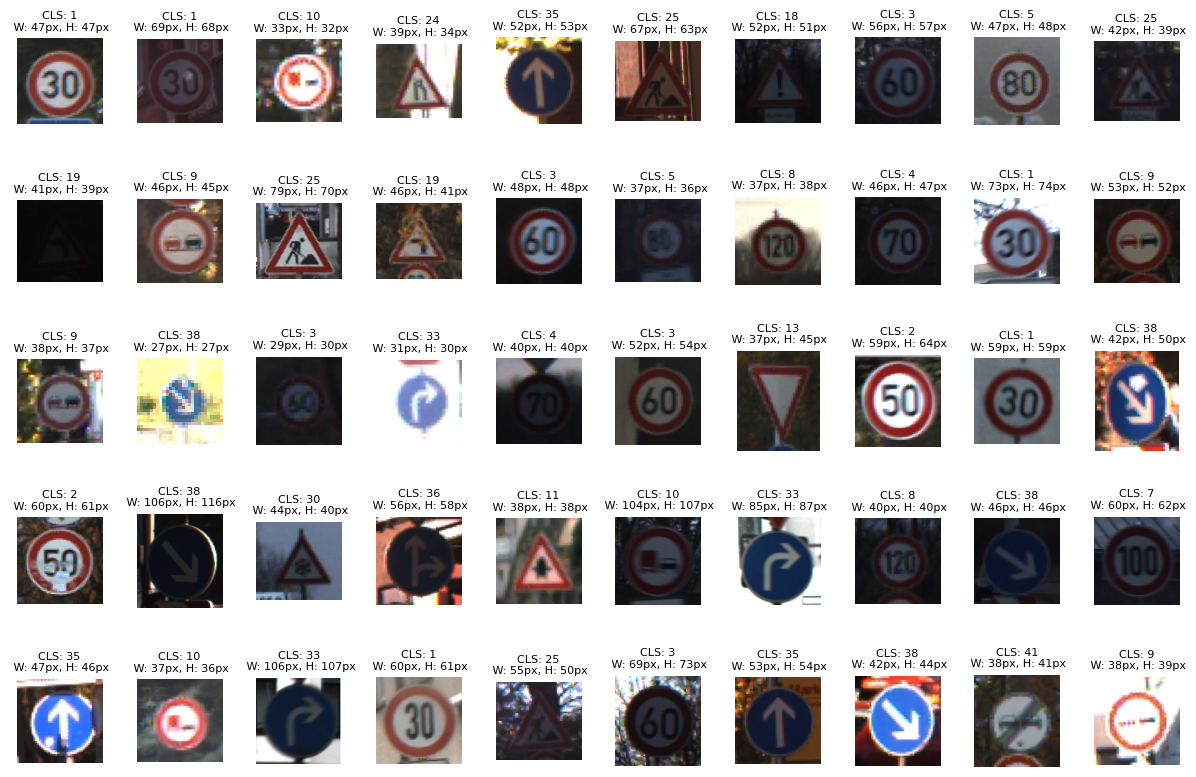

In [1]:
# Standard imports and aliases.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.v2 as T     # Use transforms v2; much more efficient.

#nota per me: transforms è ua libreria per modificare in qualsiasi modo sivoglia le immagini di un dataset(e altro).
# si usa principalemte attraverso .Compose(dentro la quale posso concatenare più operazioni  dentro parentesi quadre [])
# ad esempio :
"""
transforms.Compose([
      transforms.Resize(256),
      transforms.CenterCrop(224),
      transforms.ToTensor(),
      transforms.Normalize(
      mean=[0.485, 0.456, 0.406],
      std=[0.229, 0.224, 0.225]
)])

fonte: Deep learning with Pytorch (libro)
"""


from torchvision.datasets import GTSRB
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'


#trasformiamo il dataset GRSRB in tensore:
transform = T.Compose([T.ToTensor()])  #qui mettiamo solo la trasformazione in tensore map otremo dopo anche aggiungere altro come crop resize ecc...
ds_train = GTSRB('_data/', split='train', transform=transform, download=True)
ds_test  = GTSRB('_data/', split='test', transform=transform, download=True)


#stampiamo intanto le immagini senza alcuna modifica:
num_samples = 50
image_samples = [ds_train[idx] for idx in np.random.choice(range(len(ds_train)), num_samples)]

plt.figure(figsize=(15,20))

#padding tra le immagini per leggibilità
plt.subplots_adjust(wspace=0.4, hspace=0.6)

for (idx, (im, cls)) in enumerate(image_samples):
    plt.subplot(10, 10, idx+1)
    plt.imshow(im.permute([1, 2, 0]))
    h, w = im.shape[1], im.shape[2]
    plt.title(f'CLS: {cls}\n W: {w}px, H: {h}px', fontsize=8)
    plt.axis('off')

grayscale_transform = T.Grayscale()


Come possiamo ben osservare  le immagini hanno dimensioni diverse, luminosità, e contrasti diversi(oltre alle classi ovviamente...)
Possiamo anche andare a stampare le immagini in greyscale per approfondire il problema della luminosità.
Questi sono tutti problemi che andranno gestiti in qualche modo.

Stampa greyscale:

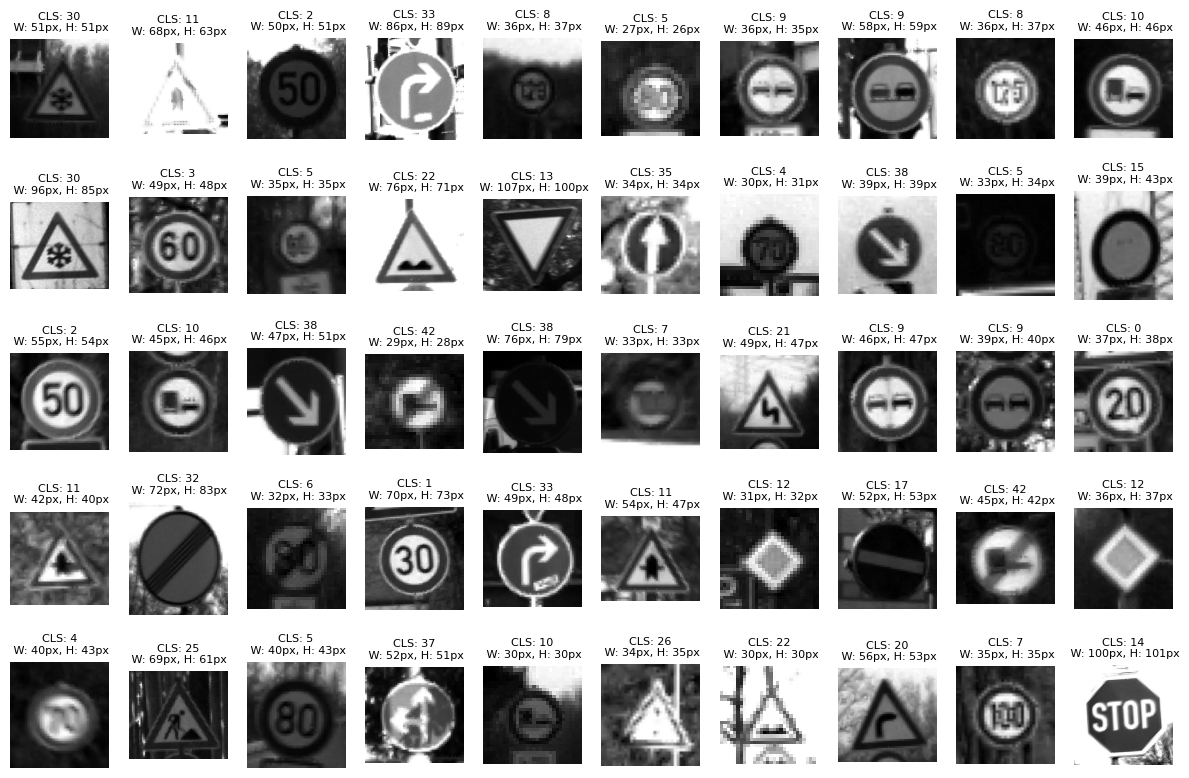

In [2]:
#padding tra le immagini per leggibilità
#plt.subplots_adjust(wspace=0.4, hspace=0.6)


plt.figure(figsize=(15,20))

for (idx, (im, cls)) in enumerate(image_samples):
    im_grey = grayscale_transform(im)
    plt.subplot(10, 10, idx+1)
    plt.imshow(im_grey.permute([1, 2, 0]), cmap='gray')
    h, w = im_grey.shape[1], im.shape[2]
    plt.title(f'CLS: {cls}\n W: {w}px, H: {h}px', fontsize=8)
    plt.axis('off')

In [3]:
Come già lo era prima si nota una sostanziosa differenza di illuminazione e contrasto tra molte immagini.

SyntaxError: invalid syntax (3344763083.py, line 1)

**Ora calcoliamo alcune statistiche possibilmente utili a riguardo**

In [6]:

#mi calcolo la luminosità come la media dei pixel dell'immagini e il contrasto come la std. mi calcolo le statistiche anche su questi due valori.
#il caloclo viene effettuato trasformando prima l'immagine in greyscale per rendere secondo me l'analisi più accurata. altrimenti si potrebbe fare per canale.

#AI GENERATED (Gemini flash 2.5) -----------------------------------------------
stats_list = []
epsilon = np.finfo(float).eps # Un piccolo valore per evitare divisioni per zero

for im, cls in ds_train:
    im_gray = grayscale_transform(im)
    mean_val = im_gray.mean().item()
    std_val = im_gray.std().item()

    rms_contrast = std_val / (mean_val + epsilon)

    stats_list.append((cls, im.shape[1], im.shape[2], mean_val, rms_contrast))
# ------------------------------------------------------------------------------

#vediamo la distribuzione delle classi e di altre caratteristiche delle immagini
#1. trasformo in dataframe
df_stats = pd.DataFrame(stats_list, columns=['CLS', 'HEIGHT', 'WIDTH', 'BRIGHTNESS', 'CONTRAST'])
df_stats['AR'] = df_stats['WIDTH'] / df_stats['HEIGHT']
#display(df_stats.head())


In [5]:
df_stats.describe()

,CLS,HEIGHT,WIDTH,BRIGHTNESS,CONTRAST,AR
count,26640.000000,26640.000000,26640.000000,26640.000000,26640.000000,26640.000000
mean,15.887387,50.365128,50.933784,0.322259,0.530904,1.008718
std,12.044099,23.161523,24.373418,0.188226,0.189205,0.072100
min,0.000000,25.000000,25.000000,0.024363,0.059368,0.368132
25%,5.000000,35.000000,35.000000,0.171013,0.405106,0.972222
50%,12.000000,43.000000,43.000000,0.292005,0.517663,1.000000
75%,25.000000,58.000000,58.000000,0.444001,0.639328,1.044444
max,42.000000,225.000000,243.000000,0.974181,1.536480,1.417808


array([[<Axes: title={'center': 'CLS'}>,
        <Axes: title={'center': 'HEIGHT'}>],
       [<Axes: title={'center': 'WIDTH'}>,
        <Axes: title={'center': 'BRIGHTNESS'}>],
       [<Axes: title={'center': 'CONTRAST'}>,
        <Axes: title={'center': 'AR'}>]], dtype=object)

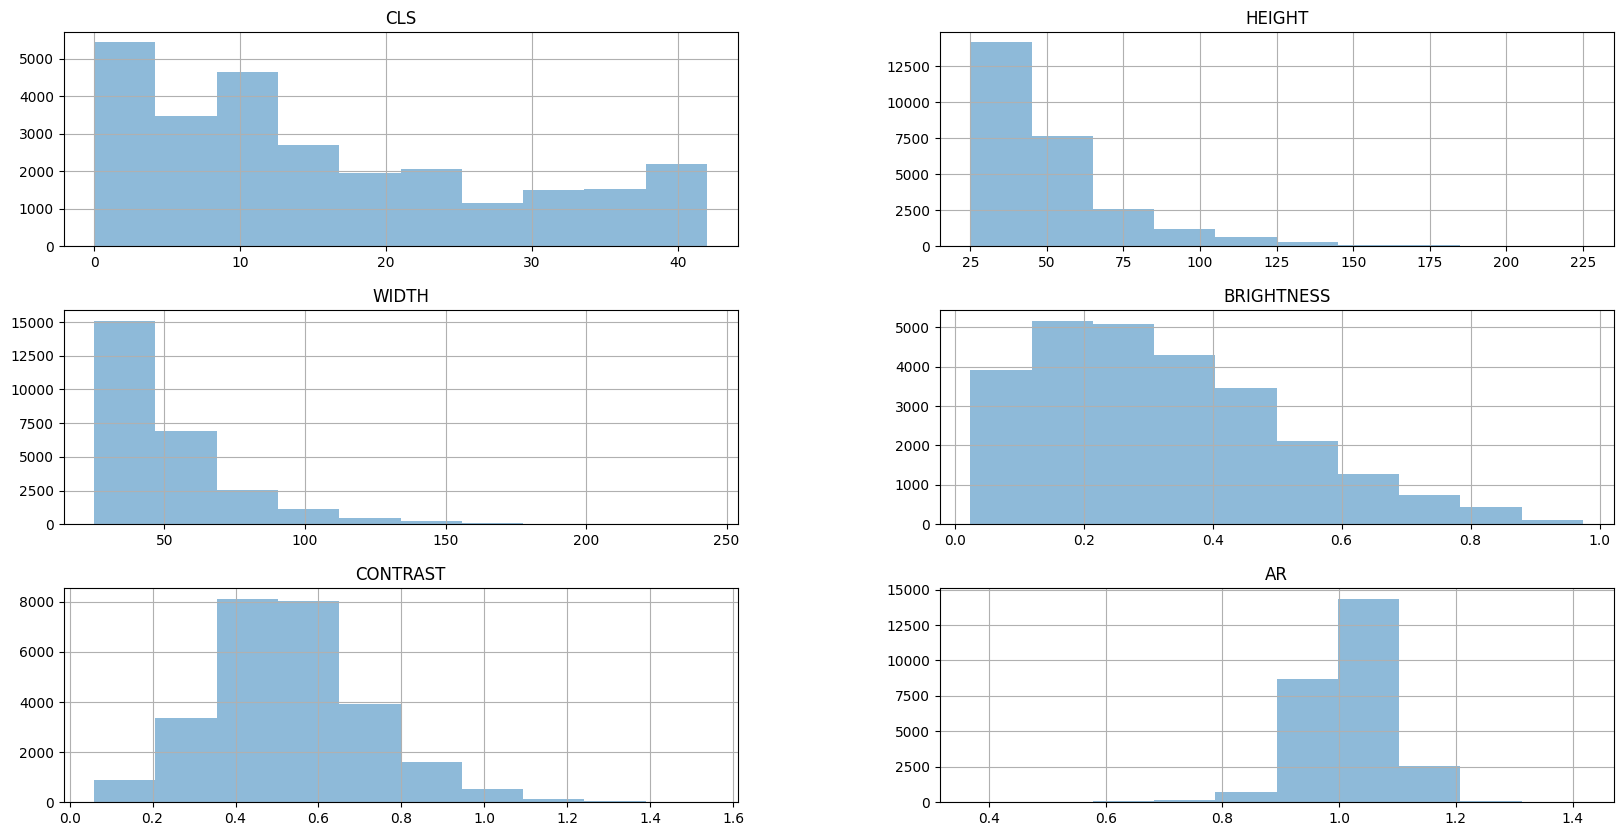

In [7]:
#setto distanza tra i grafici istogrammi per non farli sovrappore i testi:
df_stats.hist(alpha=0.5, figsize=(20, 10))

Possiamo osservare un dataset che ha:

*   Classi evidentemenete sbilanciate, anche se non eccessivamente. Vediamo dall'istogramma come le classi più frequenti raggiungano un 5000 campioni circa mentre quelle meno frequenti sui 1000 campioni circa.
Potremmo pensare di effettuare undersampling o data augmentation per bilanciare le istanze di ciascuna classe. ad esempio fare data augmentation in maniera più frequente per classi sottorappresentate.

*   Riguardo altezza e larghezza delle immagini vediamo come ci sia una distribuzione di dati molto simile, almeno fino al 75% percentile. Successivamente notiamo una sostanziale differenza tra gli "outlier" dell'altezza e della larghezza con valori addirittura fino a 225px per l'altezza e 243px per la larghezza. possiamo trarre come conclusione quella che le immagini per la grande maggioranza, come vediamo anche dagli istogrammi risultino avere dimensioni sotto i 58px. possiamo in base a questo decidere su come uniformare le immagini per darle in pasto alla rete. Ad esempio un idea è quella di andare a ridurre la dimensione più corta a un valore fisso e poi fissare a una dimensione unica tutte le immagini facendo random crop(ad ex. 64x64)

* Distribuzione del contrasto che sembra avere distr. gaussiana con pochi outliers molto estremi. A livello invece di brightness abbiamo outliers passando da 0.44 a 0.97. Risulta che potrebbe essere utile normalizzare i pixel dell'immagine per ridurre questo fenomeno.


E' interessante vedere anche come cambiano le distribuzioni applicando il log naturale. IInfatti osservando gli istogrammi di Height, Width e brightness sembra esserci right-skewness, specialmente nei primi due. ci aspettiamo una distribuzione più "normale" anche se comunque con qualche forma di asimmetria.

array([[<Axes: title={'center': 'CLS'}>,
        <Axes: title={'center': 'HEIGHT'}>],
       [<Axes: title={'center': 'WIDTH'}>,
        <Axes: title={'center': 'BRIGHTNESS'}>],
       [<Axes: title={'center': 'CONTRAST'}>,
        <Axes: title={'center': 'AR'}>]], dtype=object)

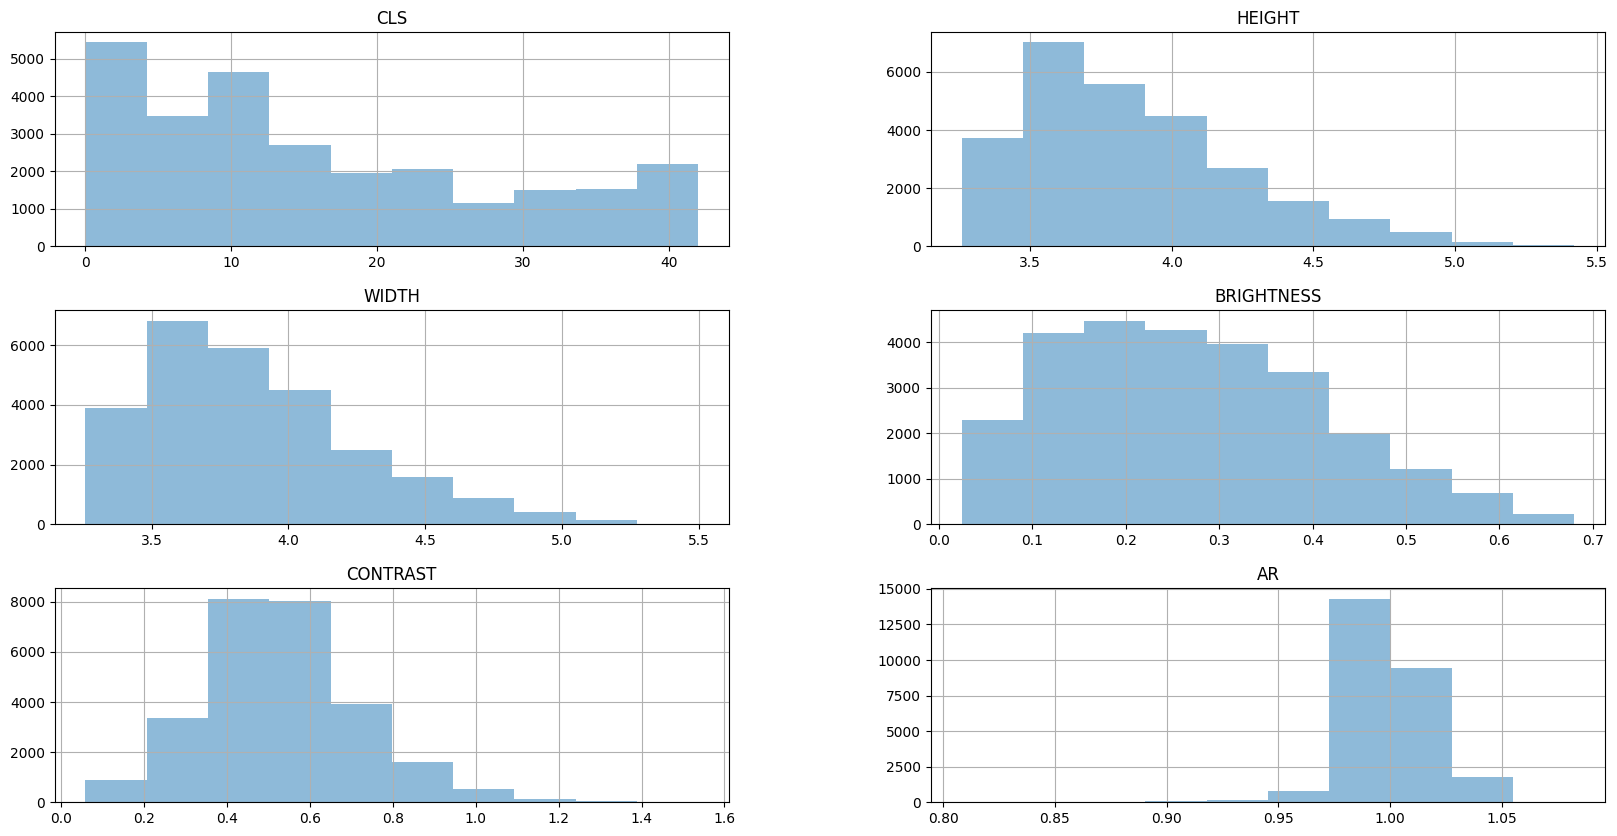

In [8]:

#mi calcolo la luminosità come la media dei pixel dell'immagini e il contrasto come la std. mi calcolo le statistiche anche su questi due valori.
#il caloclo viene effettuato trasformando prima l'immagine in greyscale per rendere secondo me l'analisi più accurata. altrimenti si potrebbe fare per canale.

import math

#AI GENERATED (Gemini flash 2.5) -----------------------------------------------
stats_list = []
epsilon = np.finfo(float).eps # Un piccolo valore per evitare divisioni per zero

for im, cls in ds_train:
    im_gray = grayscale_transform(im)
    mean_val = im_gray.mean().item()
    std_val = im_gray.std().item()

    rms_contrast = std_val / (mean_val + epsilon)

    stats_list.append((cls, np.log1p(im.shape[1]), np.log1p(im.shape[2]), np.log1p(mean_val), rms_contrast))
# ------------------------------------------------------------------------------

#vediamo la distribuzione delle classi e di altre caratteristiche delle immagini
#1. trasformo in dataframe
df_stats_log = pd.DataFrame(stats_list, columns=['CLS', 'HEIGHT', 'WIDTH', 'BRIGHTNESS', 'CONTRAST'])
df_stats_log['AR'] = df_stats_log['WIDTH'] / df_stats_log['HEIGHT']


df_stats_log.describe()

df_stats_log.hist(alpha=0.5, figsize=(20, 10))


ALTRE COSE CHE POTREI FARE:

*   vedere statistiche per classe
*   visualizzare immagini estreme
* range pixel
* valori mancanti
*   SCATTER PLOT per h e w











In [9]:
print('Valori mancanti raggruppati per classe:')
missing_per_class = df_stats.groupby('CLS').apply(lambda x: x.isnull().sum())
display(missing_per_class)

Valori mancanti raggruppati per classe:


/tmp/ipykernel_5959/117411152.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_per_class = df_stats.groupby('CLS').apply(lambda x: x.isnull().sum())


,CLS,HEIGHT,WIDTH,BRIGHTNESS,CONTRAST,AR
CLS,,,,,,
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
5,0,0,0,0,0,0
6,0,0,0,0,0,0
7,0,0,0,0,0,0
8,0,0,0,0,0,0


### Non ci sono valori mancanti all'interno del dataset.

### #Samples per classe (Class Distribution)

In [10]:
print('Number of samples per class:')
display(df_stats['CLS'].value_counts().sort_index())

Number of samples per class:


,count
CLS,
0,150
1,1500
2,1500
3,960
4,1320
5,1260
6,300
7,960
8,960


### Statistiche descrittive per classe

In [ ]:
print('Descriptive statistics for image features grouped by class:')
display(df_stats.groupby('CLS')[['HEIGHT', 'WIDTH', 'BRIGHTNESS', 'CONTRAST', 'AR']].describe())

NOTIAMO CHE: visualizzare i dati in questo modo è decisamente infattibile. Perciò proviamo a visualizzare i dati per classe in maniera più grafica di seguito:

### Visual Summary of Class Statistics

Invece di semplici tabelle visualizziamo attraverso grafici più leggibili i dati, partendo dalla distribuzione delle classi, in questo caso mostrando le frequenze precise per classe(43 in totale)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,1, figsize=(18, 6))

class_counts = df_stats['CLS'].value_counts().sort_values(ascending=False)
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis', hue=class_counts.index, legend=False)
axes.set_title('Class Distribution (Sorted by Frequency)', fontsize=14)
axes.set_xlabel('Class ID')
axes.set_ylabel('Number of Samples')


plt.tight_layout()
plt.show()

### Uso dei Box-plot
Per visualizzare le statistiche descrittive per caratteristica (per classe) usiamo un tipo di grafico molto comodo in questi casi, il box-plot.

In [ ]:
plt.figure(figsize=(18, 6))
sns.boxplot(x='CLS', y='AR', data=df_stats, palette='magma', hue='CLS', legend=False)
plt.title('Aspect ratio per Class', fontsize=14)
plt.xlabel('Class ID')
plt.ylabel('AR')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

Guardando il grafico dell'Aspect Ratio (AR) basato sui dati df_stats, ecco cosa possiamo dedurre:

- La maggior parte dei box sono centrati quasi esattamente sul valore 1.0. Questo significa che, indipendentemente dalla risoluzione, i segnali nel dataset GTSRB sono quasi tutti quadrati.

- Non ci sono classi 'storte'. Se avessimo ad esempio un box centrato su 0.5 o 2.0, significherebbe che quella specifica classe di segnali è molto stretta o molto larga. Qui invece tutte le 43 classi si comportano in modo simile.

- Notiamo un numero discreto di outlier per classe. tuttavia vedendo come i boxplot si stabilizzano intorno a circa lo stesso valore di media, supponiamo questa cosa non possa creare troppi problemi durante il training.

Potremmo quindi usare un semplice T.Resize((64, 64)) senza temere di deformare i segnali. magari effettuando prima un random crop per la dimensione meno "grande" a un numero come 70px ad esempio.

### Mostriamo anche i boxplot per BRIGHTNESS e CONTRAST


In [19]:
plt.figure(figsize=(18, 6))
sns.boxplot(x='CLS', y='BRIGHTNESS', data=df_stats, palette='coolwarm', hue='CLS', legend=False)

axes.set_title('Brightness Distribution per Class', fontsize=14)
axes.set_xlabel('Class ID')
axes.set_ylabel('Brightness Value')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(18, 6))
sns.boxplot(x='CLS', y='CONTRAST', data=df_stats, palette='coolwarm', hue='CLS', legend=False)
axes.set_title('Contrast Distribution per Class', fontsize=14)
axes.set_xlabel('Class ID')
axes.set_ylabel('RMS contrast Value')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

ValueError: Could not interpret value `BRIGHTNESS` for `y`. An entry with this name does not appear in `data`.

<Figure size 1800x600 with 0 Axes>

Notiamo una distribuzione abbastanza uniforme del valore di contrasto per le 43 classi, mentre si nota un maggiore bias tra le varie classi rispetto alla brightness, dove le medie dei valori tra le varie classi si attestano tra 0.1 e 0.6 circa. questa diversità rispetto a questa caratteristica per le immagini potrebbe creare problemi

### DATA AUUMENTATION
La data aguemntation fatta è abbastanza straightforward, facciamo un resize a 64x64, facciamo colorJitter per modificare luminosità, contrasto ecc.. e delle rotazioni tra 15 e -15. Considerato lo sbilanciamento delle classi invece andiamo ad utilizzare un weighted sampler(ovviamente con resampling...) per compensare questo problema durante l'addestramento.

In [2]:
import numpy as np
from collections import Counter
from torch.utils.data import Dataset
from PIL import Image



aug_transform = T.Compose([
    T.ToImage(),
    T.Resize((64, 64), antialias=True),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, shear=10),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [3]:
import torch
import torchvision.transforms.v2 as T
from torchvision.datasets import GTSRB
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter

aug_transform = T.Compose([
    T.ToImage(),
    T.Resize((64, 64), antialias=True),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, shear=10),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = T.Compose([
    T.ToImage(),
    T.Resize((64, 64), antialias=True),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

ds_train = GTSRB('_data/', split='train', transform=aug_transform, download=True)
ds_test  = GTSRB('_data/', split='test', transform=test_transform, download=True)

#fatto con IA(gemini)----------------:
labels = [label for _, label in ds_train._samples]

# Calcola il conteggio di ogni classe e il relativo peso. Il peso è inversamente proporzionale alla frequenza della classe
class_counts = Counter(labels)
class_weights = {class_id: 1.0 / count for class_id, count in class_counts.items()}

#Assegna il peso corrispondente a ogni campione nel dataset
sample_weights = [class_weights[label] for label in labels]

# Crea un campionatore pesato. replacement=True per estrarre lo stesso indice più volte
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
#--------------- fine IA.

### Analysis

Deep Learning is very much an *experimental* discipline. Experiments are *nothing* without analysis and interpretation. Be sure to **always** stop and analyze the results of preliminary explorations. Note anything significant and -- importantly -- anything that is going to be relevant for what comes next.

So... In this Markdown cell you should collect and report (using, for the love of God, the *rich markup capabilities of Markdown*) any relevant findings you have made before proceding.

**Important Warning**: This is the **one and only** time I will remind you of the need to provide *analysis* and interpretation of your experimental methodology and results. The responsibility is *yours* to include it elsewhere.


---
### Exercise 1.2: A Stable and Reproducible Baseline

In this exercise you should implement code to use a pretrained network as a *feature extractor* that, instead of *classifying* images in input, should return the *feature representation* from the last layer of the pretrained model before the classifier. These features, extracted from the train set, should be used to train a *classical* model for classification (e.g. an SVM, a Nearest Neighbor, or a Linear Discriminant classifier from Scikit-learn). Evaluate the performance of this baseline model on the features extracted from the test set.

In [4]:
from torchvision.models import list_models, get_model
list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [6]:
len(ds_test), len(ds_train)

(12630, 26640)

In [5]:
from torch.utils.data import DataLoader
import torch.nn as nn


batch_size = 1024
# Inserisco il sampler nel DataLoader di training
dl_train = DataLoader(ds_train, batch_size=32, sampler=sampler)
dl_test  = DataLoader(ds_test, batch_size=32, shuffle=False)

# Per ora uso direttamente resnet 50
model = get_model('resnet50', weights='DEFAULT')
model.fc = nn.Identity()  # Replace classifier with identity to extract features.
model = model.to(device)

In [6]:
from tqdm.notebook import tqdm

train_feats = []
train_classes = []
model.eval()
for (ims, cls) in tqdm(dl_train):
    ims = ims.to(device)
    with torch.no_grad():
        train_feats.append(model(ims))
    train_classes.append(cls)
train_feats = torch.vstack(train_feats).cpu()
train_classes = torch.concat(train_classes)

  0%|          | 0/833 [00:00<?, ?it/s]

In [8]:
train_feats.shape

torch.Size([26640, 2048])

In [7]:
test_feats = []
test_classes = []
model.eval()
for (ims, cls) in tqdm(dl_test):
    ims = ims.to(device)
    with torch.no_grad():
        test_feats.append(model(ims))
    test_classes.append(cls)
test_feats = torch.vstack(test_feats).cpu()
test_classes = torch.concat(test_classes)

  0%|          | 0/395 [00:00<?, ?it/s]

In [13]:

from sklearn.svm import LinearSVC

svc = LinearSVC(dual=False, verbose=1, max_iter=10000)
svc.fit(train_feats, train_classes)

[LibLinear]

KeyboardInterrupt: 

In [31]:
from sklearn.metrics import classification_report

predictions = []
# Supponendo che test_feats sia un tensore o array numpy
for i in tqdm(range(0, len(test_feats), batch_size), desc="Predicting"):
    batch_preds = svc.predict(test_feats[i:i+batch_size])
    predictions.extend(batch_preds)

KeyboardInterrupt: 


---
### Exercise 1.3: A Fine-tuning Baseline

In this exercise you should try to *improve* on the stable baseline given by the feature extraction + SVM (or whatever) classifier you produced in the previous lecture. To do this, you should *fine-tune* the ResNet-18 (or whatever model you chose) to solve the new classification task.

To do this, you could proceed by:
1. Loading the ResNet-18 (or whatever) model and replacing the final FC layer (the classifier) with a *new* classifier. This could be a single Linear layer, or could be an MLP.
2. Training the resulting model on the GTSRB dataset for a few epochs.
3. Evaluating the resulting performance.

Some things you should probably consider (especially thinking about the *next* exercise):
+ You should be monitoring not only the loss on the training set, but also a *validation* loss on an *independent* validation set. Split the training set into two datasets: one with, say, 80% of the original training samples, and another with the remaining 20%. You can use this smaller set to monitor performance and check for *overfitting*.
+ Maybe the best strategy is to not fine-tune *all* layers, but only the last few. Think about *selectively* fine-tuning layers of the network.
+ Maybe a *single* linear layer isn't the best option for the classifier. Think about using an MLP instead.

In [ ]:
# Your code here. PROBLEMS WITH SCIKITLEARN so cant finetune

---
---
## Exercise 2: Pipeline Consolidation

Consolidate your implementation. When building applications based asd on Deep Learning, you will inevitably need to run many, many experiments. So, it is *always* a good idea to engineer a reproducible pipeline that allows you to run (and re-run) experiments with different hyperparameters. In this exercise you should do exactly this: engineer a deep learning pipeline that encapsulates (at least) training and evaluation so that you can easily and reproducibly run multiple experiments and compare the results.

Some things to think about when engineering this pipeline:
- **Model and Loss (and maybe Optimizer) Abstraction**: An important variable in training deep models is the model (obviously), the loss (somewhat less obvious), and the optimizer (less obvious) used during training. Your pipeline should probably be able to adapt to these changing configurations.
- **Configuration management**: Instead of global variables specializing each cell, thread a configuration object through your code (or use a singleton). If you are planning to use an IDE and not this notebook for the lab, you might consider using a configuration management library like [OmegaConf](https://omegaconf.readthedocs.io/en/2.3_branch/) which will help instrument your code so that you can pass configuration overrides via command line arguments.
- **Logging**: You will invariably need to run and compare multiple experiments. Instrument your code for monitoring training. Good options are [Tensorboard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) or [Weights and Biases (WandB)](https://wandb.ai/site/). My PhD students seem to overwhelmingly prefer Weights and Biases. The configuration parameters should be used to facilitate distinguishing and comparing multiple runs with multiple hyperparameters.

### INSTALLIAMO DIPENDENZE PER OMEGACONF E WANDB

In [8]:
!pip install omegaconf wandb -q
from omegaconf import OmegaConf
import wandb

In [26]:
!wandb login #qu chiave

wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [21]:
wandb.login(relogin=True)   #o da qui

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tommypasto (tommypasto-university-of-florence) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [22]:
# testo una configurazione
config = {
    "train": {
        "lr": 0.001,
        "batch_size": 128,
        "epochs": 10,
        "optimizer": "Adam"
    },
    "model": {
        "name": "resnet18",
        "num_classes": 43,
        "pretrained": True
    },
    "system": {
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "seed": 42
    }
}

cfg = OmegaConf.create(config)

#test
print(f"Learning Rate: {cfg.train.lr}")

Learning Rate: 0.001


In [23]:
from torchvision.models import resnet18, resnet50, ResNet18_Weights, ResNet50_Weights

def get_traffic_sign_model(model_name, num_classes):
    """
    Istantia un modello pre-addestrato e adatta il classificatore finale.
    """

    #intanto solo resnet18 e 50
    if model_name == "resnet18":
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
    elif model_name == "resnet50":
        model = resnet50(weights=ResNet50_Weights.DEFAULT)
    else:
        raise ValueError(f"Modello {model_name} non supportato in questa funzione.")

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )

    return model

In [24]:
class GTSRB_Trainer:
    def __init__(self, cfg, train_loader, test_loader):
        self.cfg = cfg
        self.train_loader = train_loader
        self.test_loader = test_loader

        # Inizializziamo il modello usando la config
        self.model = get_traffic_sign_model(cfg.model.name, cfg.model.num_classes).to(cfg.system.device)

        self.criterion = nn.CrossEntropyLoss()

        # Seleziono l'ottimizatore
        if cfg.train.optimizer == "Adam":
            self.optimizer = torch.optim.Adam(self.model.parameters(), lr=cfg.train.lr)
        else:
            self.optimizer = torch.optim.SGD(self.model.parameters(), lr=cfg.train.lr)

        #Inizializzo WandB(questo potrei metterlo opzionale.....)
        wandb.init(project="GTSRB_Lab", config=OmegaConf.to_container(cfg))

    def fit(self):
        for epoch in range(self.cfg.train.epochs):
            self.model.train()
            total_loss = 0

            for images, labels in tqdm(self.train_loader, desc=f"Epoch {epoch+1}"):
                images, labels = images.to(self.cfg.system.device), labels.to(self.cfg.system.device)

                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()

                total_loss += loss.item()

            avg_loss = total_loss / len(self.train_loader)
            test_acc = self.evaluate()

            # LOGGING SU WANDB
            wandb.log({"epoch": epoch+1, "train_loss": avg_loss, "test_accuracy": test_acc})
            print(f"Epoch {epoch+1}: Loss {avg_loss:.4f}, Acc {test_acc:.2f}%")

    def evaluate(self):
        self.model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in self.test_loader:
                images, labels = images.to(self.cfg.system.device), labels.to(self.cfg.system.device)
                outputs = self.model(images)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
        return 100 * correct / len(self.test_loader.dataset)


finetuned_model = GTSRB_Trainer(cfg, dl_train, dl_test)
finetuned_model.fit()
wandb.finish()

Epoch 1:   0%|          | 0/833 [00:00<?, ?it/s]

Epoch 1: Loss 0.6366, Acc 90.57%


Epoch 2:   0%|          | 0/833 [00:00<?, ?it/s]

Epoch 2: Loss 0.1454, Acc 95.12%


Epoch 3:   0%|          | 0/833 [00:00<?, ?it/s]

...

Epoch 9:   0%|          | 0/833 [00:00<?, ?it/s]

Epoch 9: Loss 0.0542, Acc 95.84%


Epoch 10:   0%|          | 0/833 [00:00<?, ?it/s]

Epoch 10: Loss 0.0580, Acc 96.74%


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁▆▇▆███▆▇█
train_loss,█▂▂▁▁▁▁▁▁▁
epoch,10
test_accuracy,96.73793
train_loss,0.05801



---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK!

---
### Exercise 3.1 (Easy): Improving Fine-tuning Performance

In this exercise you are asked to iterate on the fine-tuning experiment performed in Exercise 1.3 in order to squeeze the best performance possible out of the model.

What can we do:
- Use a more powerful model?
- More aggressive data augmentation?
- Selective layer training?
- Something else?

**Why choose this exercise?** To hone your skills at incrementally improving fined-tuned model performance via a sequence of (carefully monitored) experiments.

In [ ]:
# Your code here.


---
### Exercise 3.2: Retrieval as Training-free Classification (a bit harder)

In this exercise you will treat the problem of classifying road signs as a type of retrieval problem. By doing so, will will avoid the need to perform extensive fine-tuning of our model and will instead count of the good *representations* provided by massively pretrained models.

How, you ask? In this exercise you should treat the training set as a *gallery* of indexed image descriptors and the test set as a set of *query* descriptors. You could proceed in this way:

1. **Implement** a generic *feature extraction* function that, given a model and a dataloader, will extract the feature representations of all images in the dataloader. You should make this function generic because you will of course want to try *multiple* pretrained backbones in order to pick the best one.
2. **Implement** a function to *query* the gallery using all extracted extracted from the test set. The results of this should be a *ranking* of all gallery images in terms of similarity with each test image. You should think carefully about how to compute this *similarity* score and how to compute it efficiently.
3. **Evaluate** the retrieval performance on each of the 43 classes in the GTSRB dataset using the similarity scores. This could be done using precision recall curves, average precision/recall, or other metrics.

Wait, this isn't a classifier... Well, no. But, if you use the above *pipeline* to select the best feature extraction pipeline, you can then implement a **Nearest-Mean Classifier (NMC)**: compute the *mean* feature representation of all training images for each class and *classify* test images based on which mean is **nearest** to it.

**Why choose this exercise?** To learn how to make the most out of pretrained feature extraction backbones, how to evaluate different types of learning systems (retrieval in this case), and to familiarize yourself with similarity-based classification which is extensively used in multimodal models like CLIP.

In [ ]:
# Your code here.


---
### Exercise 3.3: *Detecting* Traffic Signs (hardest)

In this exercise you will see if you can take your pretrained *classification* backbone and turn it into a *detector*. We will need another dataset for this -- one with *full image frames* instead of cropped sign images. Luckily, this dataset is available on [Hugging Face](https://huggingface.co/datasets/keremberke/german-traffic-sign-detection) (see below for how to access it).

For this exercise, you could:
1. Start from an available Faster-RCNN model from `torchvision` and *replace* the feature extraction backbone with your ResNet fine-tuned on GTRSB.
2. This *stitched-together* network should do an OK-ish job already of detecting at least *some* traffic signs. See how it performs on some of the images from the GTRSB Detection dataset. Implement a simple function to visualize detections superimposed over the original image. Compute some detection metrics (accuracy @ IoU=0.5, for example).
3. If you're feeling ambitious, you could also *fine-tune* the resulting model to improve detection performance.

**NOTE**: The pretrained Faster-RCNN models in `torchvision` are all based on ResNet-50, so this exercise will likely be much less painful if you use a ResNet-50 from the very start.

**Also Note**: To use the **GTRSB Detection Dataset** you should use the `datasets` package from Hugging Face (version 3.X):

     # If using uv.
     uv add datasets==3

or

     # If using Anaconda
     conda install -c conda-forge datasets==3

In [ ]:
from datasets import load_dataset

# Download the full detection dataset from the Hugging Face Hub.
# You will want to spend some time studying the organization of this dataset.
ds = load_dataset("keremberke/german-traffic-sign-detection", name="full")

#fonte per come usare il modello base: https://youtu.be/qC4yEiJOJtM
frcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained = True)

In [ ]:
frcnn_model

In [ ]:
#metto una "classe" in più per come è strutturato frcnn
num_classes = 44
in_features = frcnn_model.roi_heads.box_predictor.cls_score.in_features
frcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

In [ ]:
#estraggo pesi dal mio modello (CON IA(gemini)------)
my_model_state = finetuned_model.model.state_dict()
backbone_weights = {k: v for k, v in my_model_state.items() if not k.startswith('fc.')}

In [ ]:
# Carico il mio resnet50 fine-tunato al posto dell'attuale backbone
frcnn_model.backbone.body.load_state_dict(backbone_weights, strict=False)
#fine IA-----------------------------------------------------------------

In [ ]:
#testiamo
frcnn_model.to(device)
frcnn_model.eval()

---
---